In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# maf=1e-3
# n = !wc -l $eur_samples_path
# n_eur = int(n[0].split(' ')[0])
# mac = maf*(2*n_eur)

mac = 20

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [3]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
variant_class = "missense"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

abexp_min,loftee_hc,strand,id,score_pai3d,absplice2_max,gpn_score,promoterai,five_prime_utr_variant_consequence_uaug_lost,delta_score,consequence_missense_variant,cadd_raw,abexp_abs_max,consequence_start_lost,promoterai_abs,verphylop,consequence_splice_acceptor_variant,am_pathogenicity,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_uaug_gained,dist_to_tss,consequence_synonymous_variant,consequence_stop_gained,absplice_dna_max,consequence_splice_donor_variant,tss,region,gpn_star_llr_calibrated_mean,gene_name,consequence_frameshift_variant,five_prime_utr_variant_consequence_ustop_lost,consequence_stop_lost,esmscoremissense,gene_length,pangolin_score
f32,i8,str,str,f32,f32,f32,f32,u8,f32,i32,f32,f32,i32,f32,f32,i32,f32,u8,u8,i64,i32,i32,f32,i32,i64,str,f32,str,i32,u8,i32,f32,i64,f32
-0.140443,0,"""-1""","""chr1:177946510:G:A""",0.793948,0.002355,-8.17,0.0,0,0.03,1,5.289581,0.140443,0,0.0,9.96,0,0.748,0,0,37793,0,0,0.011,0,177984303,"""ENSG00000120341""",-7.272596,"""SEC16B""",0,0,0,-7.779,60349,0.04
-0.112486,0,"""-1""","""chr1:177960806:T:A""",0.49196,0.000854,-7.59,0.0,0,0.0,1,2.316195,0.112486,0,0.0,-0.001,0,0.2993,0,0,23497,0,0,0.003,0,177984303,"""ENSG00000120341""",-5.665048,"""SEC16B""",0,0,0,-2.685,60349,0.01
-0.126506,0,"""-1""","""chr1:177942016:G:A""",0.795879,0.000982,-7.46,0.0,0,0.12,1,5.857862,0.126506,0,0.0,10.03,0,0.2027,0,0,42287,0,0,0.005,0,177984303,"""ENSG00000120341""",-7.034506,"""SEC16B""",0,0,0,-7.18,60349,0.03
-0.093468,0,"""-1""","""chr9:132925608:A:G""",0.0,0.001386,-4.21,0.0,0,0.06,0,1.301943,0.093468,0,0.0,1.1,0,0.0,0,0,21266,1,0,0.004,0,132946874,"""ENSG00000165699""",-4.20307,"""TSC1""",0,0,0,0.0,55528,0.09
-0.005501,0,"""-1""","""chr1:177937377:C:T""",0.0,0.000034,-0.07,0.0,0,0.03,0,-0.167611,0.005501,0,0.0,-2.216,0,0.0,0,0,46926,1,0,0.0,0,177984303,"""ENSG00000120341""",0.110868,"""SEC16B""",0,0,0,0.0,60349,0.03
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,1,"""1""","""chr16:56892946:CCTGCAG:C""",0.0,0.0,-1.41,0.0,0,0.0,0,0.28051,0.0,0,0.0,0.129,1,0.0,0,0,27740,0,0,0.0,0,56865206,"""ENSG00000070915""",null,"""SLC12A3""",0,0,0,0.0,50645,0.0
0.0,1,"""-1""","""chr10:16913993:C:CT""",0.0,0.0,-1.41,0.0,0,0.0,0,0.28051,0.0,0,0.0,0.129,1,0.0,0,0,215818,0,0,0.0,0,17129811,"""ENSG00000107611""",null,"""CUBN""",0,0,0,0.0,305847,0.0
0.0,1,"""-1""","""chr19:4512617:C:CCACATTCATGGCA…",0.0,0.0,-1.41,0.0,0,0.0,0,0.28051,0.0,0,0.0,0.129,0,0.0,0,0,5869,0,0,0.0,0,4518486,"""ENSG00000167676""",null,"""PLIN4""",1,0,0,0.0,16296,0.0


In [ ]:
selected_annos = anno_config_df.filter(
    pl.col('category').is_in(['vep_consequences']) # VEP CDS consequences
    # (pl.col('category').is_in(['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation'])) # missense
    # (pl.col('category').is_in(['splicing', 'genetic_diversity', 'conservation'])) # synonymous
    # (pl.col('category').is_in(['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'])) # non coding

    # (pl.col('category').is_in(['conservation', 'regulatory_nondir', 'genetic_diversity'])) # 5UTR
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr1:177946510:G:A""","""ENSG00000120341""","""consequence_frameshift_variant""",0.0
"""chr1:177960806:T:A""","""ENSG00000120341""","""consequence_frameshift_variant""",0.0
"""chr1:177942016:G:A""","""ENSG00000120341""","""consequence_frameshift_variant""",0.0
"""chr9:132925608:A:G""","""ENSG00000165699""","""consequence_frameshift_variant""",0.0
"""chr1:177937377:C:T""","""ENSG00000120341""","""consequence_frameshift_variant""",0.0
…,…,…,…
"""chr16:56892946:CCTGCAG:C""","""ENSG00000070915""","""consequence_synonymous_variant""",0.0
"""chr10:16913993:C:CT""","""ENSG00000107611""","""consequence_synonymous_variant""",0.0
"""chr19:4512617:C:CCACATTCATGGCA…","""ENSG00000167676""","""consequence_synonymous_variant""",0.0


In [5]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [6]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [7]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(352, 1176)

In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")

    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')

Executing the full lazy plan with the streaming engine...


In [9]:
# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    correlation_df
    .select(["region", "gene_name", "phenotype", "annotation", "n_variants", "correlation"])
    .join(
        anno_config_df, on='annotation'
    )
    .join(
        gene_trait_df[['region', 'phenotype', 'corr_dir']], on=['region', 'phenotype']
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('corr_dir')*pl.col('annotation_dir')
    )
)
print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (9408, 12)


region,gene_name,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_dir,corr_beta
str,str,str,str,u64,f64,str,str,str,i64,f64,f64
"""ENSG00000100578""","""KIAA0586""","""trunk_predicted_mass_int""","""consequence_synonymous_variant""",1104,0.031214,"""vep_consequences""","""#C6DBEF""","""VEP Synonymous""",1,-1.0,-0.031214
"""ENSG00000253729""","""PRKDC""","""seated_height_int""","""consequence_stop_gained""",2931,-0.064806,"""vep_consequences""","""#FB9A99""","""VEP Stop Gained""",1,-1.0,0.064806
"""ENSG00000196712""","""NF1""","""white_blood_cell_leukocyte_cou…","""consequence_stop_lost""",1752,NaN,"""vep_consequences""","""#FFB300""","""VEP Stop Lost""",1,1.0,NaN
"""ENSG00000101670""","""LIPG""","""hdl_cholesterol_int""","""consequence_frameshift_variant""",407,0.179062,"""vep_consequences""","""#E31A1C""","""VEP Frameshift""",1,1.0,0.179062
"""ENSG00000173250""","""GPR151""","""trunk_fat_percentage_int""","""consequence_splice_acceptor_va…",304,NaN,"""vep_consequences""","""#AB47BC""","""VEP Splice Acceptor""",1,1.0,NaN
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000169047""","""IRS1""","""trunk_predicted_mass_int""","""consequence_splice_donor_varia…",952,NaN,"""vep_consequences""","""#6A1B9A""","""VEP Splice Donor""",1,-1.0,NaN
"""ENSG00000084674""","""APOB""","""apolipoprotein_a_int""","""consequence_splice_donor_varia…",2854,0.009099,"""vep_consequences""","""#6A1B9A""","""VEP Splice Donor""",1,1.0,0.009099
"""ENSG00000143365""","""RORC""","""urate_int""","""consequence_missense_variant""",323,-0.003356,"""vep_consequences""","""#1E90FF""","""VEP Missense""",1,1.0,-0.003356


In [24]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name', 'phenotype'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)  # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'gene_name', 'phenotype'], how='inner')
filt_corr_df

region,gene_name,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_dir,corr_beta,n_annotations
str,str,str,str,u64,f64,str,str,str,i64,f64,f64,u64
"""ENSG00000169174""","""PCSK9""","""ldl_direct_int""","""consequence_start_lost""",609,-0.087248,"""vep_consequences""","""#E65100""","""VEP Start Lost""",1,-1.0,0.087248,8
"""ENSG00000010803""","""SCMH1""","""standing_height_int""","""consequence_synonymous_variant""",475,-0.074772,"""vep_consequences""","""#C6DBEF""","""VEP Synonymous""",1,1.0,-0.074772,8
"""ENSG00000122729""","""ACO1""","""haematocrit_percentage_int""","""consequence_frameshift_variant""",615,0.139822,"""vep_consequences""","""#E31A1C""","""VEP Frameshift""",1,1.0,0.139822,8
"""ENSG00000170471""","""RALGAPB""","""peak_expiratory_flow_pef_int""","""consequence_splice_donor_varia…",887,-0.108857,"""vep_consequences""","""#6A1B9A""","""VEP Splice Donor""",1,-1.0,0.108857,8
"""ENSG00000010327""","""STAB1""","""platelet_distribution_width_in…","""consequence_stop_gained""",2385,0.014814,"""vep_consequences""","""#FB9A99""","""VEP Stop Gained""",1,1.0,0.014814,8
…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000188487""","""INSC""","""vitamin_d_int""","""consequence_splice_donor_varia…",409,0.016381,"""vep_consequences""","""#6A1B9A""","""VEP Splice Donor""",1,-1.0,-0.016381,8
"""ENSG00000157766""","""ACAN""","""arm_predicted_mass_right_int""","""consequence_stop_lost""",1637,-0.00633,"""vep_consequences""","""#FFB300""","""VEP Stop Lost""",1,-1.0,0.00633,8
"""ENSG00000135776""","""ABCB10""","""mean_corpuscular_volume_int""","""consequence_stop_lost""",592,0.069923,"""vep_consequences""","""#FFB300""","""VEP Stop Lost""",1,-1.0,-0.069923,8


In [25]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


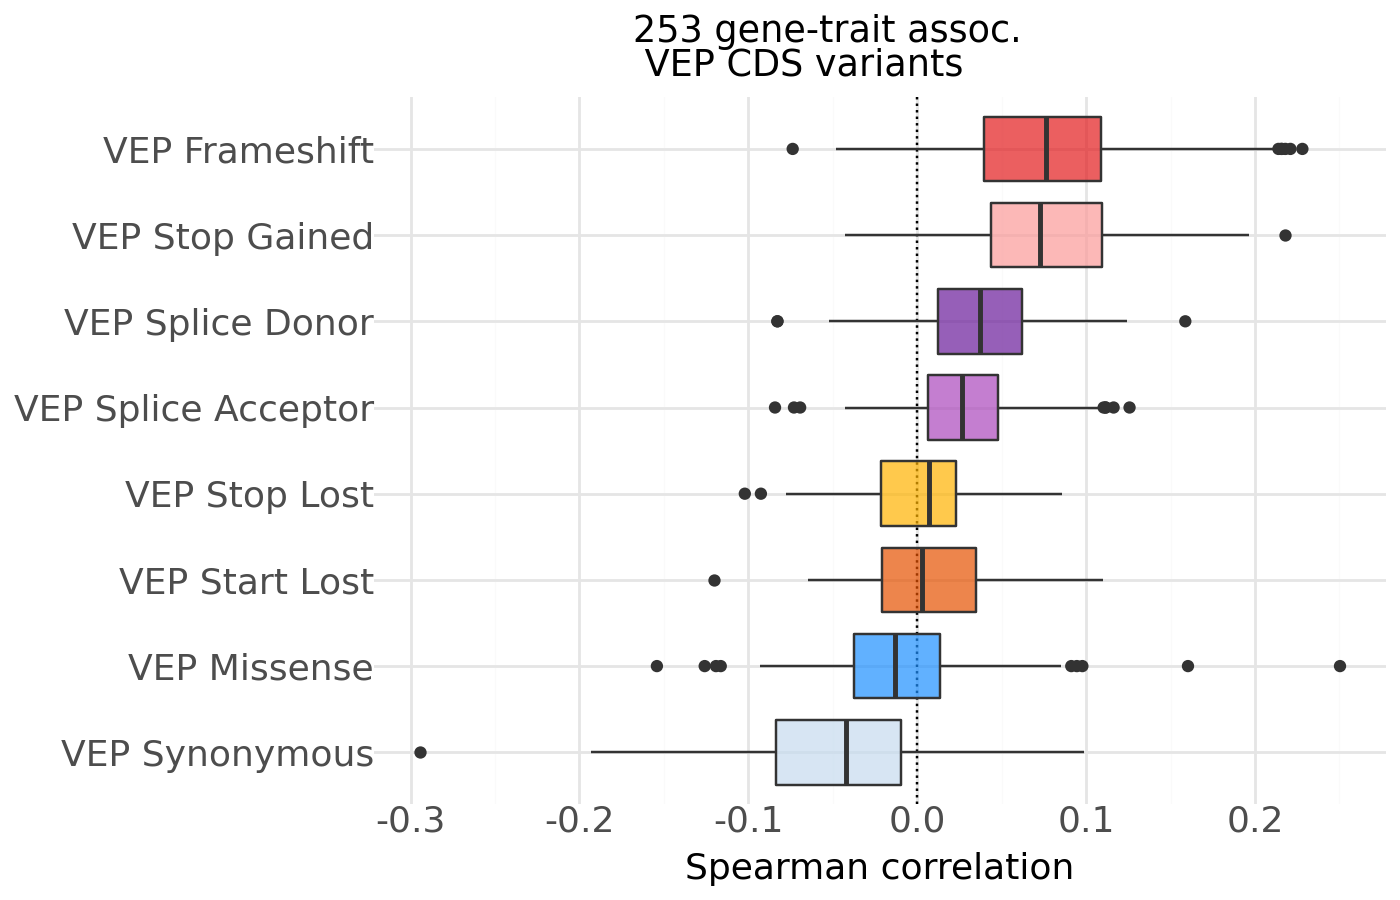

In [42]:
# Prepare for plotting
med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta = pl.col("corr_beta").median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation"))
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc. \
        \n VEP CDS variants"
        # \n Disorder region missense variants"
        # \nGene body ±10kb"
        # \n{variant_class} variants"
        # \nTSS [{min_range}bp, {max_range}bp]"
    )
    + coord_flip()
    + theme(
        figure_size=(7, 4.5),
        legend_position="none",
        # axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [23]:
med_df.sort('median_corr_beta')

annotation,median_corr_beta
str,f64
"""consequence_synonymous_variant""",-0.042233
"""consequence_missense_variant""",-0.014502
"""consequence_start_lost""",0.005008
"""consequence_stop_lost""",0.006758
"""consequence_splice_acceptor_va…",0.027534
"""consequence_splice_donor_varia…",0.037914
"""consequence_stop_gained""",0.072399
"""consequence_frameshift_variant""",0.076787


In [14]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_550983/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""consequence_synonymous_variant""","""consequence_frameshift_variant""",253,340.0,1.6344e-41
"""consequence_synonymous_variant""","""consequence_stop_gained""",253,664.0,6.8470e-40
"""consequence_stop_gained""","""consequence_start_lost""",253,389.0,3.3283e-39
"""consequence_missense_variant""","""consequence_stop_gained""",253,1009.0,3.3578e-38
"""consequence_stop_lost""","""consequence_stop_gained""",253,977.0,3.6645e-36
…,…,…,…,…
"""consequence_splice_acceptor_va…","""consequence_start_lost""",253,8753.0,3.4715e-10
"""consequence_synonymous_variant""","""consequence_missense_variant""",253,8986.0,1.2312e-9
"""consequence_missense_variant""","""consequence_start_lost""",253,11050.0,0.000017


In [15]:
stats_df.filter(
    (pl.col('VSM_A') == 'absplice2_max') | (pl.col('VSM_B') == 'absplice2_max')
)

VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
